In [4]:
from src.feature_builder import big_table
df = big_table()
df.head()

,Driver,TeamName,Year,EventName,IsSprint,RecentQForm,driver_points_last_3,team_points_last_3,WeekendRainFlag,AvgPreQualiTemp,...,SessionRank_SQ,SessionRank_SS,TheoreticalDelta_FP1,TheoreticalDelta_FP2,TheoreticalDelta_FP3,TheoreticalDelta_Q,TheoreticalDelta_SQ,TheoreticalDelta_SS,Q_Rank_LastYear,Q_Delta_LastYear
0,ALB,Williams,2022,Abu Dhabi Grand Prix,0,14.000000,0.0,0.0,0,43.975238,...,NaN,NaN,1.151,1.617,1.027,2.204,NaN,NaN,NaN,NaN
1,ALB,Williams,2022,Australian Grand Prix,0,15.000000,0.0,0.0,0,32.075949,...,NaN,NaN,3.002,2.746,1.752,2.003,NaN,NaN,NaN,NaN
2,ALB,Williams,2022,Austrian Grand Prix,1,15.000000,0.0,0.0,0,38.452475,...,18.0,NaN,1.190,1.262,NaN,1.359,1.915,NaN,NaN,NaN
3,ALB,Williams,2022,Azerbaijan Grand Prix,0,17.666667,2.0,2.0,0,45.661702,...,NaN,NaN,3.011,3.462,2.418,3.287,NaN,NaN,NaN,NaN
4,ALB,Williams,2022,Belgian Grand Prix,0,15.333333,0.0,0.0,0,20.267187,...,NaN,NaN,0.922,2.013,1.760,1.614,NaN,NaN,NaN,NaN


In [5]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor

# 1. Kopiujemy dane z Feature Buildera
data = df.copy()

# 2. Usuwamy kolumny tekstowe lub zamieniamy je na liczby (Label Encoding)
le = LabelEncoder()
for col in ["Driver", "TeamName", "EventName"]:
    if col in data.columns:
        data[col] = le.fit_transform(data[col].astype(str))

# 3. Definiujemy cel: przewidujemy pozycję w kwalifikacjach
target_col = "SessionRank_Q"

# ANTI-LEAKAGE SHIELD: Szukamy wszystkich kolumn kwalifikacyjnych oprócz targetu
q_columns = [
    col for col in data.columns if col.endswith("_Q") and col != target_col
]

meta_columns = ["TeamSlug"]
columns_to_drop = q_columns + meta_columns + [target_col]

# Pozostawiamy do usunięcia tylko te, które faktycznie istnieją w tabeli
columns_to_drop = [c for c in columns_to_drop if c in data.columns]

X = data.drop(columns=columns_to_drop)
y = data[target_col]

# Usuwamy wiersze, w których target jest pusty
X = X[y.notna()]
y = y.dropna()

# 4. Chronologiczny podział danych (Szeregi czasowe)
train_mask = X["Year"] < 2025
test_mask = X["Year"] == 2025

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

# Usuwamy kolumnę 'Year' ze zbiorów cech
X_train = X_train.drop(columns=["Year"])
X_test = X_test.drop(columns=["Year"])

# 5. Inicjalizacja i pętla treningowa 5 modeli
print("=== TRENOWANIE MODELI ===")
models = {
    "Ridge": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(n_estimators=150, max_depth=4, random_state=1, n_jobs=-1),
    "XGBoost": xgb.XGBRegressor(n_estimators=150, learning_rate=0.05, max_depth=4, random_state=67, n_jobs=-1),
    "LightGBM": lgb.LGBMRegressor(n_estimators=150, learning_rate=0.05, max_depth=4, random_state=1, n_jobs=-1, verbose=-1),
    "CatBoost": CatBoostRegressor(iterations=150, learning_rate=0.05, depth=4, random_state=1, verbose=0)
}

# Słownik przechowujący wyniki przewidywań każdego modelu
predictions_dict = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions_dict[name] = model.predict(X_test)
    print(f"[{name}] Zakończono trenowanie.")

print("Wszystkie modele gotowe do ewaluacji!")

Model został pomyślnie wytrenowany
True


=== METRYKI PORÓWNAWCZE MODELI ===
Model                MAE     RMSE
---------------------------------
XGBoost            2.916    3.672
Random Forest      3.005    3.678


TOP 10 NAJWAŻNIEJSZYCH CECH – XGBOOST:
               Cecha Ważność
         RecentQForm  0.2451
driver_points_last_3  0.1341
  team_points_last_3  0.0972
     SessionRank_FP3  0.0552
     SessionRank_FP2  0.0517
      SessionRank_SQ  0.0314
TheoreticalDelta_FP1  0.0268
   DeltaToLeader_FP1  0.0261
   DeltaToLeader_FP2  0.0250
    Q_Delta_LastYear  0.0241
--------------------------------------------------
TOP 10 NAJWAŻNIEJSZYCH CECH – RANDOM FOREST:
               Cecha Ważność
         RecentQForm  0.5239
driver_points_last_3  0.1175
  team_points_last_3  0.1066
     SessionRank_FP3  0.0820
     SessionRank_FP2  0.0457
TheoreticalDelta_FP1  0.0228
   DeltaToLeader_FP3  0.0140
   DeltaToLeader_FP2  0.0108
    Q_Delta_LastYear  0.0108
   DeltaToLeader_FP1  0.0104




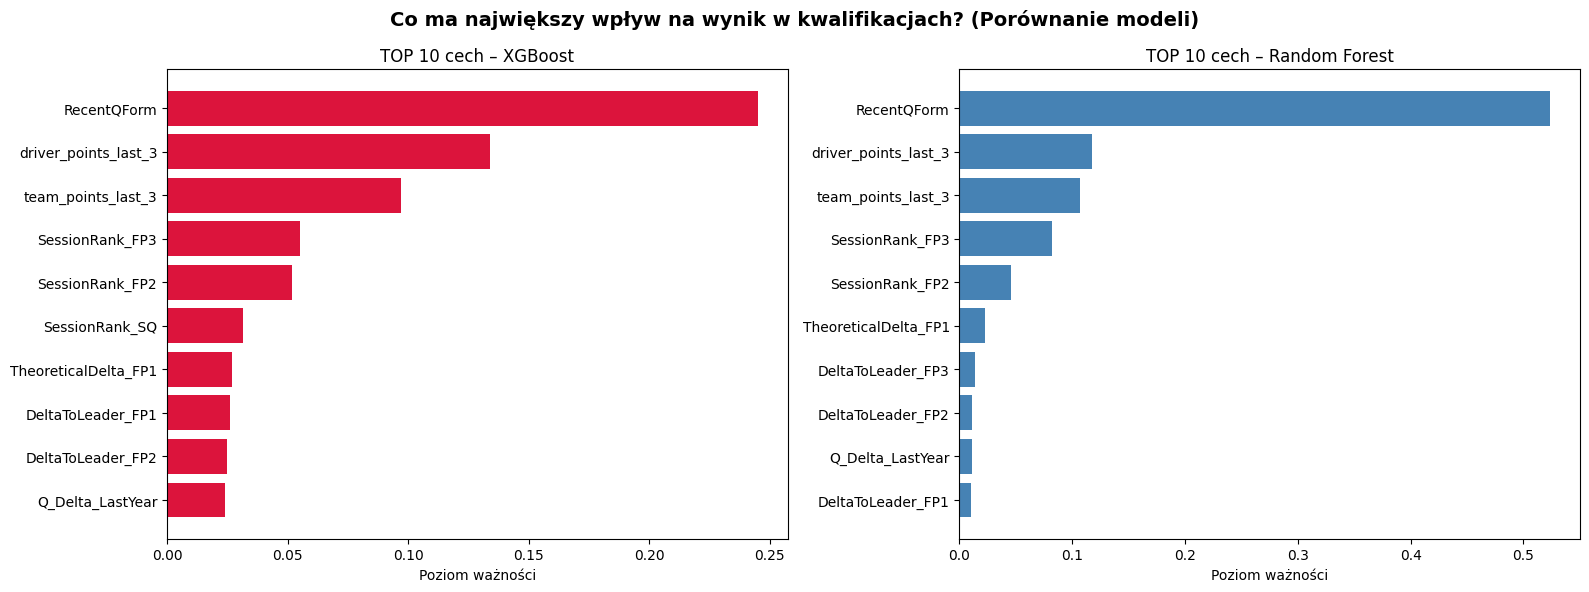

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error
import shap

print("=== 1. BIZNESOWE METRYKI PORÓWNAWCZE MODELI ===")
results_dict = {}

# Obliczamy metryki dla wszystkich modeli ze słownika
for name, preds in predictions_dict.items():
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))

    # Customowa metryka (Top-3 Accuracy dla zgadywanego Pole Position)
    temp_results = pd.DataFrame({
        'Event_ID': X_test['EventName'],
        'Actual_Rank': y_test,
        'Predicted_Score': preds
    })
    temp_results['Predicted_Rank'] = temp_results.groupby('Event_ID')['Predicted_Score'].rank(method='first')
    top_predictions = temp_results[temp_results['Predicted_Rank'] == 1]
    top3_acc = (top_predictions['Actual_Rank'] <= 3).mean() * 100

    results_dict[name] = {'MAE': mae, 'RMSE': rmse, 'Top3_Accuracy[%]': top3_acc}

# Tworzymy i wyświetlamy posortowaną tabelę wyników
results_df = pd.DataFrame(results_dict).T
results_df = results_df.sort_values(by='Top3_Accuracy[%]', ascending=False)
print("-" * 55)
print(results_df.to_string(float_format="{:.3f}".format))
print("-" * 55 + "\n")


print("=== 2. WAZNOSC CECH (XGBoost vs Random Forest) ===")
# Wyciągamy konkretne modele do analizy cech
model_xgb = models["XGBoost"]
model_rf = models["Random Forest"]

# Budujemy ramki ważności (niezależne sortowanie)
df_imp_xgb = pd.DataFrame(
    {"Cecha": X_train.columns, "Ważność": model_xgb.feature_importances_}
).sort_values(by="Ważność", ascending=False)

df_imp_rf = pd.DataFrame(
    {"Cecha": X_train.columns, "Ważność": model_rf.feature_importances_}
).sort_values(by="Ważność", ascending=False)

# Wypisujemy dokładne wartości tekstowe Top 10 do konsoli
print("\nTOP 10 NAJWAŻNIEJSZYCH CECH – XGBOOST:")
print(df_imp_xgb.head(10).to_string(index=False, formatters={"Ważność": "{:.4f}".format}))
print("-" * 50)
print("TOP 10 NAJWAŻNIEJSZYCH CECH – RANDOM FOREST:")
print(df_imp_rf.head(10).to_string(index=False, formatters={"Ważność": "{:.4f}".format}))
print("\n" + "=" * 50 + "\n")

# Rysujemy wykresy słupkowe
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_10_xgb = df_imp_xgb.head(10)
axes[0].barh(top_10_xgb["Cecha"][::-1], top_10_xgb["Ważność"][::-1], color="crimson")
axes[0].set_title("TOP 10 cech – XGBoost")
axes[0].set_xlabel("Poziom ważności")

top_10_rf = df_imp_rf.head(10)
axes[1].barh(top_10_rf["Cecha"][::-1], top_10_rf["Ważność"][::-1], color="steelblue")
axes[1].set_title("TOP 10 cech – Random Forest")
axes[1].set_xlabel("Poziom ważności")

plt.suptitle("Co ma największy wpływ na wynik w kwalifikacjach? (Porównanie)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


print("\n=== 3. WYJAŚNIALNOŚĆ MODELU (SHAP DLA ZWYCIĘZCY) ===")
print("Generowanie wykresu SHAP (Może potrwać kilka sekund)...")

# Wykorzystujemy SHAP na modelu XGBoost do sprawdzenia ukrytych korelacji
explainer = shap.TreeExplainer(model_xgb)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10, 6))
plt.title("Analiza SHAP: Jak cechy wpływają na wynik?", fontsize=14, fontweight="bold")
shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.show()